In [ ]:
from __future__ import annotations

import pathlib
import re
import sqlite3
from datetime import datetime

import polars
from matplotlib import pyplot as plt

_ = polars.Config.set_tbl_rows(100)

In [ ]:
monitoring_data_file = '../data/ifum/01Oct25174700/monitoring.db'
log_file = '../data/ifum/01Oct25174700/alignment_agent.log'

In [ ]:
def load_monitoring_db(monitoring_db: pathlib.Path):
    conn = sqlite3.connect(monitoring_db)
    query = """
    SELECT task.task_id, task.task_func_name, try.task_try_time_launched, task.task_time_returned
    FROM task
    LEFT JOIN try
    ON task.task_id == try.task_id
    """
    df = polars.read_database(
        query=query,
        connection=conn,
    )

    df = (
        df.with_columns(
            [
                polars.col('task_try_time_launched')
                .str.to_datetime(None)
                .alias('start'),
                polars.col('task_time_returned')
                .str.to_datetime(None)
                .alias('end'),
            ],
        )
        .with_columns(
            [
                (
                    (
                        polars.col('start') - polars.col('start').min()
                    ).dt.total_milliseconds()
                    / 1000
                ).alias('timestamp'),
            ],
        )
        .sort('timestamp')
        .with_columns(
            (
                (
                    polars.col('end') - polars.col('start')
                ).dt.total_milliseconds()
                / 1000
                # .clip(0)
            ).alias('duration'),
        )
    )
    return df

In [ ]:
def load_log_events(log_file: pathlib.Path, start_time: datetime.DateTime):
    event_lines = []
    with open(log_file) as f:
        for line in f:
            if 'START' in line or 'END' in line:
                event_lines.append(line)

    log_pattern = re.compile(
        r'\[(?P<timestamp>[\d\-:\. ]+)\] '
        r'.*?\b(?P<event_type>START|END)\b'
        r'(?P<task>\S+) (?P<uuid>[a-f0-9\-]{36})',
    )
    events = []
    for line in event_lines:
        matches = log_pattern.search(line)
        if matches:
            data = matches.groupdict()
            # Optionally, parse timestamp string to a datetime object
            data['timestamp'] = datetime.strptime(
                data['timestamp'],
                '%Y-%m-%d %H:%M:%S.%f',
            )
            events.append(data)

    df = polars.from_dicts(events)
    df = df.with_columns(
        [
            (
                (polars.col('timestamp') - start_time).dt.total_milliseconds()
                / 1000
            ).alias('timestamp'),
        ],
    ).sort('timestamp')
    df = (
        df.group_by(['uuid', 'task'])
        .agg(
            [
                polars.col('timestamp')
                .filter(polars.col('event_type') == 'START')
                .alias('start'),
                polars.col('timestamp')
                .filter(polars.col('event_type') == 'END')
                .alias('end'),
            ],
        )
        .drop('uuid')
        .with_columns(
            [
                polars.col('start').list.first(),
                polars.col('end').list.first(),
            ],
        )
        .with_columns(polars.col('end').fill_null(polars.col('start').max()))
        .sort(['start', 'end'])
        .with_columns(
            (polars.col('end') - polars.col('start'))
            .clip(0)
            .alias('duration'),
        )
    )
    return df

In [ ]:
df = load_monitoring_db(monitoring_data_file)
df

task_id,task_func_name,task_try_time_launched,task_time_returned,start,end,timestamp,duration
i64,str,str,str,datetime[μs],datetime[μs],f64,f64
0,"""_run_agent_on_worker""","""2025-10-01 19:35:46.731749""","""2025-10-01 20:25:52.476453""",2025-10-01 19:35:46.731749,2025-10-01 20:25:52.476453,0.0,3005.744
1,"""_run_agent_on_worker""","""2025-10-01 19:35:46.739504""","""2025-10-01 20:25:52.476932""",2025-10-01 19:35:46.739504,2025-10-01 20:25:52.476932,0.007,3005.737
2,"""load_files""","""2025-10-01 19:35:57.373778""","""2025-10-01 19:36:01.152982""",2025-10-01 19:35:57.373778,2025-10-01 19:36:01.152982,10.642,3.779
4,"""load_files""","""2025-10-01 19:35:57.385992""","""2025-10-01 19:36:01.218095""",2025-10-01 19:35:57.385992,2025-10-01 19:36:01.218095,10.654,3.832
6,"""load_files""","""2025-10-01 19:35:57.389657""","""2025-10-01 19:36:01.104966""",2025-10-01 19:35:57.389657,2025-10-01 19:36:01.104966,10.657,3.715
8,"""load_files""","""2025-10-01 19:35:57.391791""","""2025-10-01 19:36:01.265256""",2025-10-01 19:35:57.391791,2025-10-01 19:36:01.265256,10.66,3.873
10,"""load_files""","""2025-10-01 19:35:57.395783""","""2025-10-01 19:36:01.165176""",2025-10-01 19:35:57.395783,2025-10-01 19:36:01.165176,10.664,3.769
12,"""load_files""","""2025-10-01 19:35:57.400022""","""2025-10-01 19:36:01.078141""",2025-10-01 19:35:57.400022,2025-10-01 19:36:01.078141,10.668,3.678
14,"""load_files""","""2025-10-01 19:35:57.404125""","""2025-10-01 19:36:01.100880""",2025-10-01 19:35:57.404125,2025-10-01 19:36:01.100880,10.672,3.696


In [ ]:
agent_events = load_log_events(log_file, df['start'].min())
agent_events

task,start,end,duration
str,f64,f64,f64
"""alignment-exec""",28.847,29.211,0.364
"""alignment-exec""",29.211,32.422,3.211
"""alignment-exec""",32.424,58.837,26.413
"""alignment-exec""",58.838,107.934,49.096
"""alignment-exec""",107.948,206.781,98.833
"""alignment-exec""",114.501,184.914,70.413
"""alignment-exec""",184.949,265.401,80.452
"""alignment-exec""",206.814,278.92,72.106
"""alignment-exec""",265.402,336.849,71.447


In [ ]:
def partition_events(events, colors, num_workers=100):
    worker_events = {i: [] for i in range(num_workers)}
    worker_colors = {i: [] for i in range(num_workers)}
    sorted_events = sorted(events, key=lambda e: (e[0], e[1]))
    last_worker = 0
    for event in sorted_events:
        corrected = (event[0], event[1])
        worker_events[last_worker].append(corrected)
        worker_colors[last_worker].append(colors[event[2]])
        last_worker = (last_worker + 1) % num_workers
    return worker_events, worker_colors

In [ ]:
def partition_events_tiled(events, num_workers=2):
    worker_events_combined = {i: [] for i in range(num_workers)}
    for event in events:
        for _, worker_events in worker_events_combined.items():
            if len(events) == 0:
                worker_events.append(event)
                break
            # There is some asynchronicity in logging the end of a
            # task so we assumed two tasks could've run on the same
            # worker if the are within 1 ms end time of each other.
            prior_end = (worker_events[-1][0] + worker_events[-1][1]) - 0.001
            if prior_end < event[0]:
                worker_events.append(event)
                break
        else:
            print('BAD', event)
    return worker_events_combined

In [ ]:
def plot_gantt(
    raw,
    parsl_events,
    parsl_colors,
    agent_events,
) -> None:
    fig, axs = plt.subplots(1, 1)

    max_x, max_y = (
        raw['timestamp'].max() + 10,
        len(parsl_events) + (5 * len(agent_events)) + 5,
    )

    sep_bars = []
    index = 0
    for worker, events in parsl_events.items():
        axs.broken_barh(
            events,
            (index, 0.75),
            facecolor=parsl_colors[worker],
            # label=task,
        )
        index += 1

    sep_bars.append(index)
    index += 5

    for _, events in agent_events.items():
        axs.broken_barh(
            events,
            (index, 4),
            # facecolor=colors[worker],
            # label=task,
        )
        index += 5

    for y in sep_bars:
        # axs.broken_barh([(0, max_x)], (y+0.5, 0.25), facecolor='black')
        axs.axhline(y + 2.5, xmin=0, xmax=max_x, linewidth=2, color='black')

    axs.grid(False)
    axs.set(
        ylim=[-0.5, max_y + 0.5],
        xlim=[0, max_x],
    )
    axs.set_xlabel('Runtime (s)', fontsize=10)
    axs.set_yticks(
        [50, 110],
        labels=[
            'Stateless\nWorkers',
            'Academy\nAgents',
        ],
    )
    axs.tick_params('y', length=0, width=0, which='major')
    axs.tick_params(axis='both', which='major', labelsize=10)

    fig.tight_layout()
    plt.draw()
    fig.set_size_inches(7, 2.5)
    fig.savefig('figures/ifum-gantt-large.pdf')

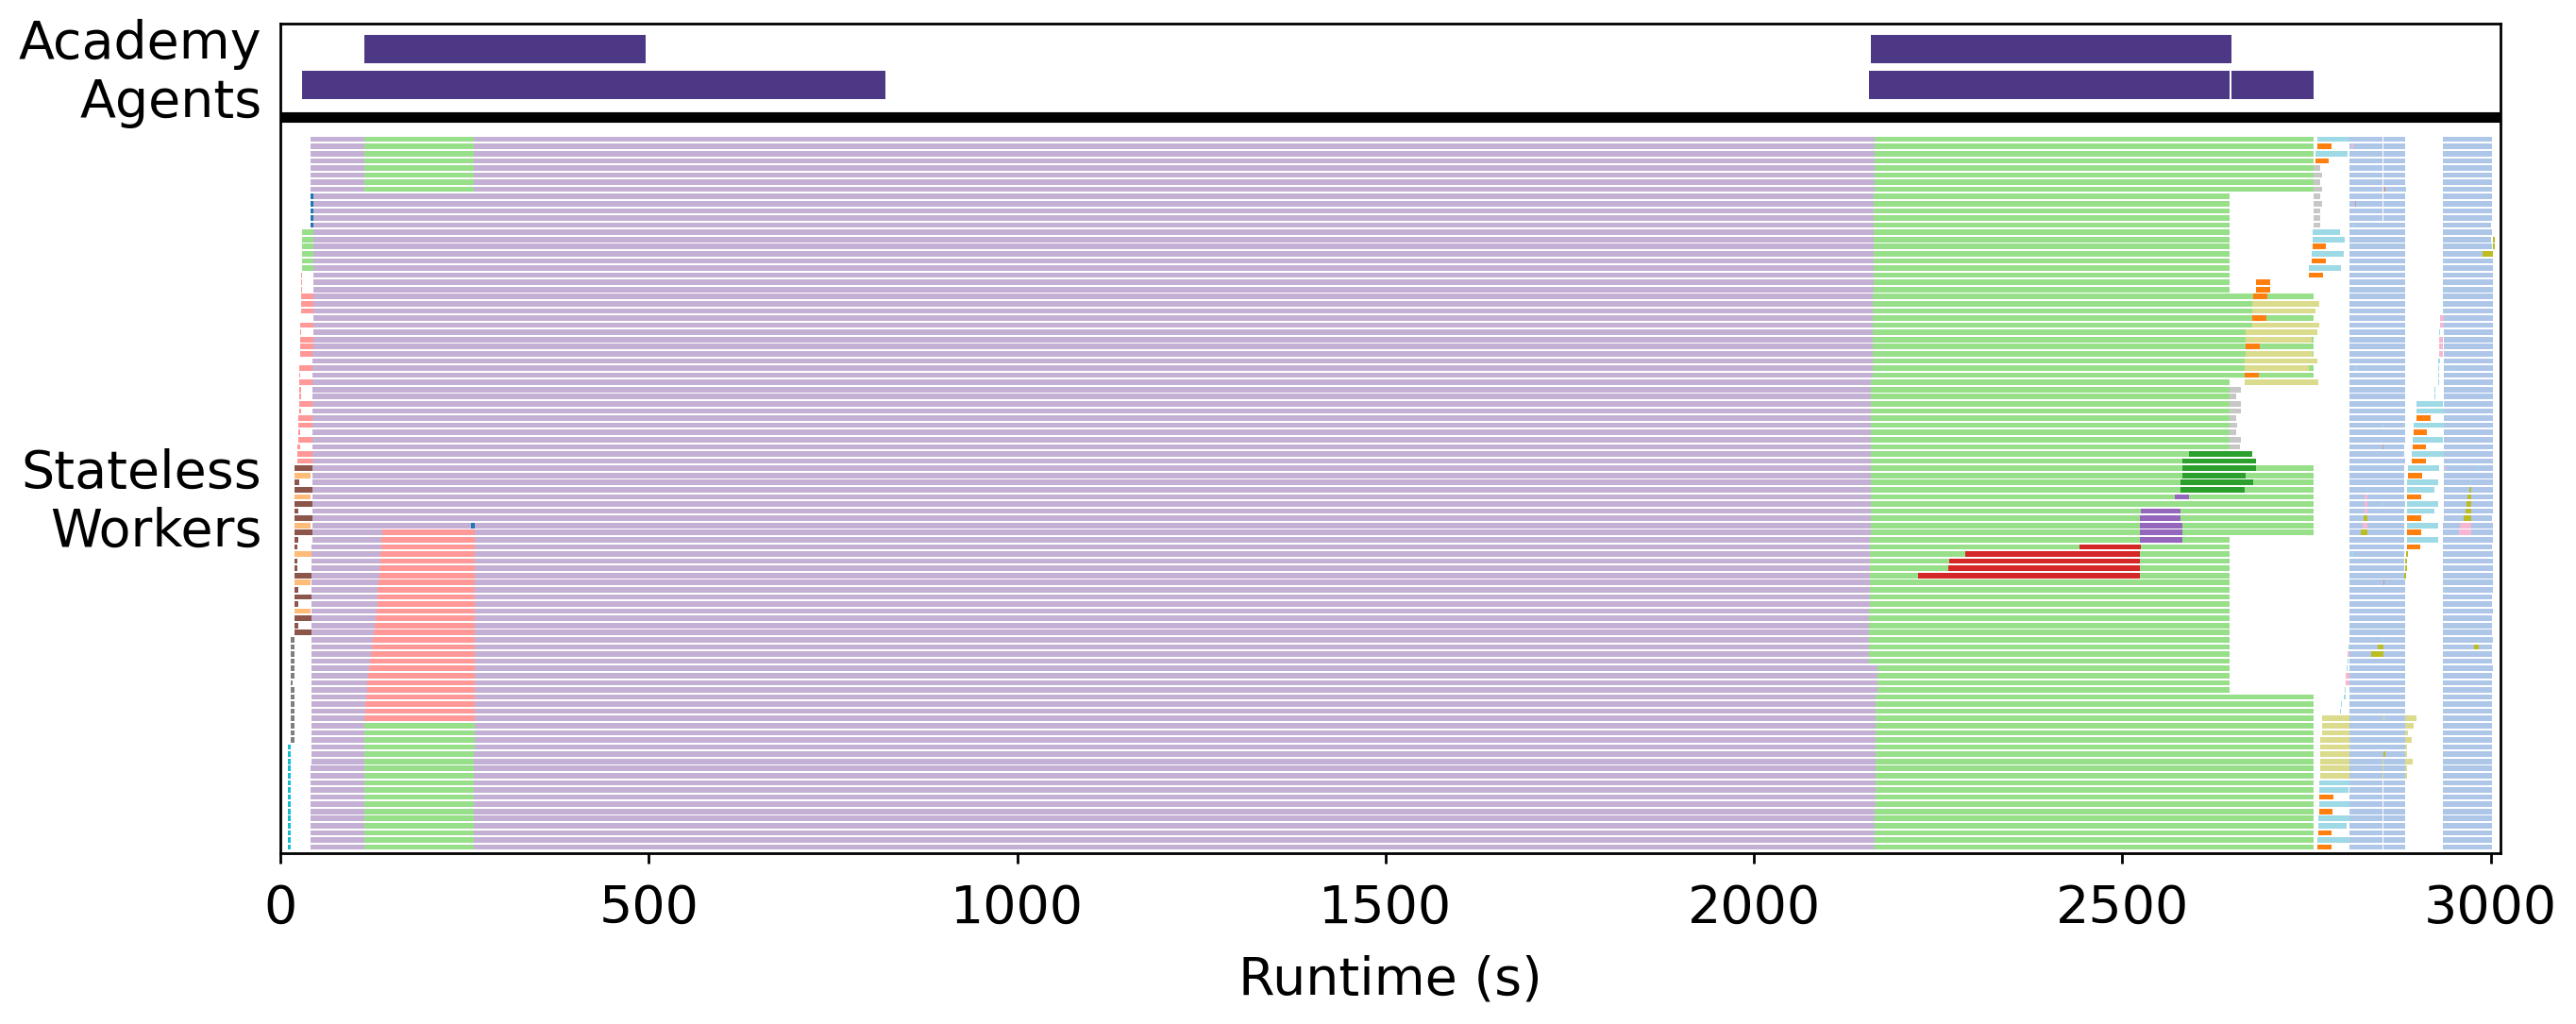

In [ ]:
def load_and_plot():
    raw = load_monitoring_db(monitoring_data_file)
    cmap = plt.cm.tab20
    colors = {
        task_name[0]: cmap(i)
        for i, task_name in enumerate(
            raw.select('task_func_name').unique().rows(),
        )
    }

    events = (
        raw.filter(polars.col('task_func_name') != '_run_agent_on_worker')
        .select('timestamp', 'duration', 'task_func_name')
        .rows()
    )
    partitioned, worker_colors = partition_events(events, colors)
    agent_raw = load_log_events(log_file, df['start'].min())
    agent_events = partition_events_tiled(
        agent_raw.select('start', 'duration').rows(),
    )
    plot_gantt(raw, partitioned, worker_colors, agent_events)


load_and_plot()